<a href="https://colab.research.google.com/github/UniCandice/McKinsey-prep/blob/main/GPU_status_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
list(Path.cwd().glob('*.csv'))

[]

In [108]:
df=pd.read_csv('/content/coreweave_gpu_classification_practice_final.csv')

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2418 entries, 0 to 2417
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Datetime                    2413 non-null   object 
 1   Node_ID                     2418 non-null   object 
 2   Operating_Mode              2418 non-null   object 
 3   GPU_Utilization_pct         2418 non-null   float64
 4   GPU_Temperature_C           2358 non-null   float64
 5   GPU_Power_W                 2357 non-null   float64
 6   GPU_Clock_MHz               2346 non-null   float64
 7   GPU_Memory_Utilization_pct  2334 non-null   float64
 8   VRAM_Used_GB                2418 non-null   float64
 9   PCIe_TX_GB_s                2358 non-null   float64
 10  PCIe_RX_GB_s                2418 non-null   float64
 11  Network_TX_GB_s             2418 non-null   float64
 12  Network_RX_GB_s             2345 non-null   float64
 13  CPU_Utilization_pct         2418 

In [110]:
df.head()

,Datetime,Node_ID,Operating_Mode,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status
0,2026-01-01 00:00:00,gpu-node-03,High Load,89.72,85.00,363.78,1657.3,84.40,52.76,8.630,9.474,14.645,17.776,51.55,53.01,1
1,2026-01-01 01:00:00,gpu-node-01,High Load,80.20,77.41,301.37,1627.4,77.47,60.59,8.025,10.632,11.976,12.023,54.87,40.22,0
2,2026-01-01 02:00:00,gpu-node-02,Normal,69.36,72.98,262.51,1732.4,62.95,46.48,NaN,7.686,7.595,9.776,37.76,42.38,0
3,2026-01-01 03:00:00,gpu-node-04,Normal,62.09,70.17,288.57,1452.2,59.50,35.43,5.649,9.480,10.548,8.643,67.93,43.76,0
4,2026-01-01 04:00:00,gpu-node-04,High Load,90.58,NaN,386.89,1772.0,94.48,62.80,10.291,10.265,11.718,14.458,77.32,62.81,0


In [111]:
df['Datetime']=pd.to_datetime(df['Datetime'],yearfirst=True,errors='coerce')

In [112]:
df.isna().sum()

,0
Datetime,10
Node_ID,0
Operating_Mode,0
GPU_Utilization_pct,0
GPU_Temperature_C,60
GPU_Power_W,61
GPU_Clock_MHz,72
GPU_Memory_Utilization_pct,84
VRAM_Used_GB,0
PCIe_TX_GB_s,60


In [113]:
df[df['Datetime'].isna()]

,Datetime,Node_ID,Operating_Mode,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status
124,NaT,gpu-node-04,Normal,59.75,67.98,258.08,1682.9,52.62,37.51,6.893,6.897,7.800,11.049,57.84,46.25,0
324,NaT,gpu-node-02,Idle,16.59,37.55,139.92,1310.1,15.92,12.32,2.841,1.779,5.084,3.623,23.19,21.91,0
432,NaT,gpu-node-01,Idle,7.84,34.30,84.39,1260.6,20.41,3.74,0.963,2.232,3.983,1.193,18.07,16.57,0
665,NaT,gpu-node-02,High Load,97.15,87.30,391.08,1751.4,76.84,68.41,10.281,10.839,14.085,14.403,68.92,73.07,0
695,NaT,gpu-node-04,Normal,67.06,71.16,313.39,1624.6,67.60,47.60,5.654,8.505,11.651,9.911,17.27,39.03,0
986,NaT,gpu-node-02,High Load,98.86,86.85,389.93,1801.3,100.00,72.82,10.616,12.789,14.915,13.534,74.95,77.57,1
1235,NaT,gpu-node-02,High Load,88.07,82.68,333.27,1811.5,71.86,60.27,8.146,8.507,11.602,10.178,57.72,60.13,0
1964,NaT,gpu-node-04,Normal,54.90,62.54,231.93,1619.3,43.13,40.07,6.591,5.615,8.530,8.854,38.41,44.70,0
2245,NaT,gpu-node-02,High Load,100.00,90.12,399.42,1903.3,84.93,63.11,8.274,11.896,11.812,15.672,65.62,63.45,1
2254,NaT,gpu-node-03,Normal,59.20,71.24,253.44,1598.4,45.88,43.42,6.683,5.503,6.880,11.064,31.77,38.09,0


In [114]:
df.dropna(subset=['Datetime'],inplace=True)

In [115]:
df.isna().sum()

,0
Datetime,0
Node_ID,0
Operating_Mode,0
GPU_Utilization_pct,0
GPU_Temperature_C,60
GPU_Power_W,61
GPU_Clock_MHz,72
GPU_Memory_Utilization_pct,84
VRAM_Used_GB,0
PCIe_TX_GB_s,60


In [116]:
df=df.sort_values(['Datetime'],ascending=True).reset_index(drop=True)

In [117]:
df.Datetime.is_monotonic_increasing

True

In [118]:
df['t/s']=(df['Datetime']-df['Datetime'].min()).dt.total_seconds()

In [119]:
df['dt']=df['t/s'].diff()
df.loc[0,'dt']=0

In [120]:
df.tail()

,Datetime,Node_ID,Operating_Mode,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status,t/s,dt
2403,2026-04-18 07:00:00,gpu-node-01,Normal,57.69,67.67,247.76,1509.2,48.78,39.51,6.142,7.260,8.206,10.080,57.19,57.06,0,9270000.0,3600.0
2404,2026-04-18 08:00:00,gpu-node-03,Normal,59.69,70.13,239.20,1677.8,48.58,46.20,5.752,7.150,8.539,9.382,52.64,56.55,0,9273600.0,3600.0
2405,2026-04-18 09:00:00,gpu-node-01,High Load,96.84,89.25,378.70,1742.4,86.31,69.29,10.438,10.122,13.603,15.613,74.66,56.84,1,9277200.0,3600.0
2406,2026-04-18 10:00:00,gpu-node-01,Normal,55.98,70.19,194.12,1441.4,68.99,42.08,5.593,4.219,6.544,10.241,34.03,48.03,0,9280800.0,3600.0
2407,2026-04-18 11:00:00,gpu-node-03,High Load,95.97,85.86,358.73,1893.1,79.50,68.34,9.427,10.756,14.220,15.296,46.75,61.45,1,9284400.0,3600.0


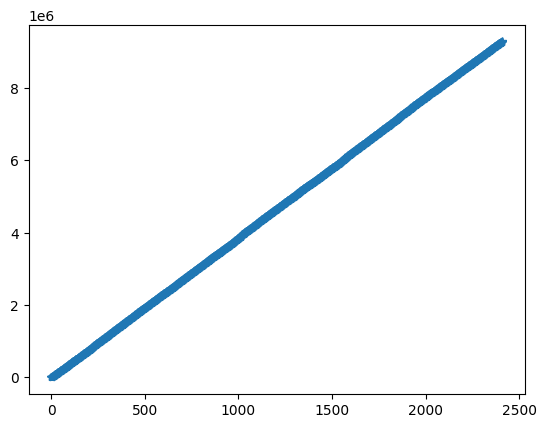

In [121]:
plt.plot(df['t/s'],'*')

In [122]:
df[df.duplicated(subset=['Datetime'],keep=False)]

,Datetime,Node_ID,Operating_Mode,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status,t/s,dt
111,2026-01-05 20:00:00,gpu-node-01,Idle,8.03,38.80,81.25,1268.3,8.09,6.51,1.581,0.170,4.643,1.754,7.21,26.13,0,417600.0,3600.0
112,2026-01-05 20:00:00,gpu-node-01,Idle,8.03,38.80,81.25,1268.3,8.09,6.51,1.581,0.170,4.643,1.754,7.21,26.13,0,417600.0,0.0
134,2026-01-06 20:00:00,gpu-node-03,Normal,59.61,68.83,252.22,1543.7,53.04,34.26,8.176,5.582,9.575,NaN,49.88,62.90,0,504000.0,3600.0
135,2026-01-06 20:00:00,gpu-node-03,Normal,59.61,68.83,252.22,1543.7,53.04,34.26,8.176,5.582,9.575,NaN,49.88,62.90,0,504000.0,0.0
180,2026-01-08 20:00:00,gpu-node-04,Normal,51.33,54.19,261.64,1534.0,65.43,38.15,5.836,5.196,5.931,10.806,41.59,51.11,0,676800.0,3600.0
181,2026-01-08 20:00:00,gpu-node-04,Normal,51.33,54.19,261.64,1534.0,65.43,38.15,5.836,5.196,5.931,10.806,41.59,51.11,0,676800.0,0.0
853,2026-02-08 01:00:00,gpu-node-03,Normal,56.32,63.77,249.92,1631.0,51.71,42.91,4.867,6.637,10.289,10.722,35.82,31.71,0,3286800.0,3600.0
854,2026-02-08 01:00:00,gpu-node-03,Normal,56.32,63.77,249.92,1631.0,51.71,42.91,4.867,6.637,10.289,10.722,35.82,31.71,0,3286800.0,0.0
1066,2026-02-17 17:00:00,gpu-node-03,High Load,90.70,81.37,320.91,1776.2,73.48,67.49,7.184,11.240,15.814,14.083,55.87,72.11,0,4122000.0,3600.0
1067,2026-02-17 17:00:00,gpu-node-03,High Load,90.70,81.37,320.91,1776.2,73.48,67.49,7.184,11.240,15.814,14.083,55.87,72.11,0,4122000.0,0.0


In [123]:
df=df.drop_duplicates(subset='Datetime')

In [124]:
df[df.duplicated(subset=['Datetime'],keep=False)]

,Datetime,Node_ID,Operating_Mode,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status,t/s,dt


In [125]:
df['t/s'].is_monotonic_increasing

True

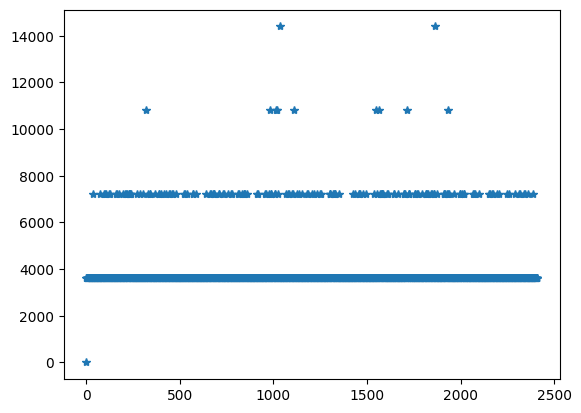

In [126]:
plt.plot(df['dt'],'*')

In [127]:
df.isna().sum()

,0
Datetime,0
Node_ID,0
Operating_Mode,0
GPU_Utilization_pct,0
GPU_Temperature_C,60
GPU_Power_W,60
GPU_Clock_MHz,72
GPU_Memory_Utilization_pct,84
VRAM_Used_GB,0
PCIe_TX_GB_s,60


In [128]:
sensor_col=[col for col in df.columns if col not in ['dt','t/s','GPU_Health_Status','Node_ID','Operating_Mode','Datetime']]

In [129]:
df=df.set_index('Datetime')

In [130]:
df.index

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 01:00:00',
               '2026-01-01 02:00:00', '2026-01-01 03:00:00',
               '2026-01-01 04:00:00', '2026-01-01 05:00:00',
               '2026-01-01 06:00:00', '2026-01-01 07:00:00',
               '2026-01-01 08:00:00', '2026-01-01 09:00:00',
               ...
               '2026-04-18 02:00:00', '2026-04-18 03:00:00',
               '2026-04-18 04:00:00', '2026-04-18 05:00:00',
               '2026-04-18 06:00:00', '2026-04-18 07:00:00',
               '2026-04-18 08:00:00', '2026-04-18 09:00:00',
               '2026-04-18 10:00:00', '2026-04-18 11:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=2390, freq=None)

In [132]:
df[sensor_col]=df[sensor_col].interpolate(method='time')

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2390 entries, 2026-01-01 00:00:00 to 2026-04-18 11:00:00
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Node_ID                     2390 non-null   object 
 1   Operating_Mode              2390 non-null   object 
 2   GPU_Utilization_pct         2390 non-null   float64
 3   GPU_Temperature_C           2390 non-null   float64
 4   GPU_Power_W                 2390 non-null   float64
 5   GPU_Clock_MHz               2390 non-null   float64
 6   GPU_Memory_Utilization_pct  2390 non-null   float64
 7   VRAM_Used_GB                2390 non-null   float64
 8   PCIe_TX_GB_s                2390 non-null   float64
 9   PCIe_RX_GB_s                2390 non-null   float64
 10  Network_TX_GB_s             2390 non-null   float64
 11  Network_RX_GB_s             2390 non-null   float64
 12  CPU_Utilization_pct         2390 non-null   float64
 1

<Axes: >

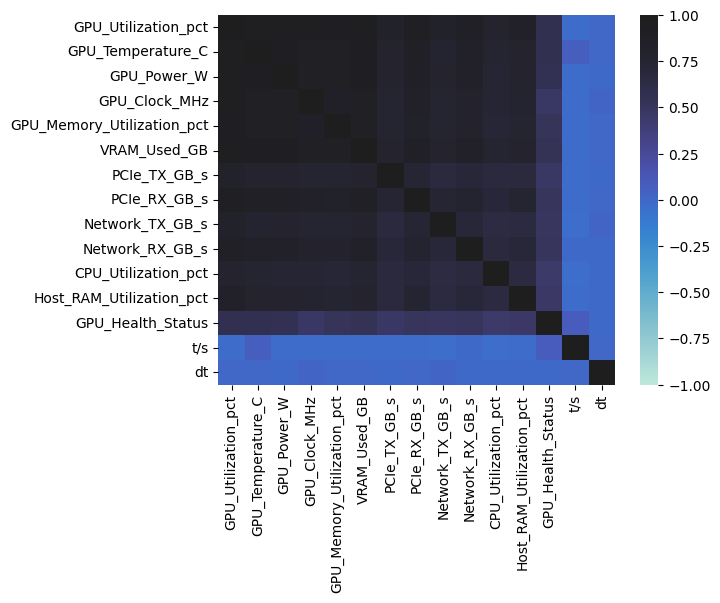

In [138]:
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),vmin=-1.0,vmax=1.0,center=1.0)

In [139]:
df_after_cleaning=df.copy()

In [156]:
df=df_after_cleaning.copy()

In [157]:
df['Operating_Mode'].value_counts()

,count
Operating_Mode,
Normal,1336
High Load,707
Idle,277
normal,24
idle,23
High load,12
NORMAL,11


In [158]:
df['Operating_Mode']=df['Operating_Mode'].replace(['normal','NORMAL'],'Normal')
df['Operating_Mode']=df['Operating_Mode'].replace(['idle '],'Idle')
df['Operating_Mode']=df['Operating_Mode'].replace(['High load'],'High Load')

In [159]:
df['Operating_Mode'].value_counts()

,count
Operating_Mode,
Normal,1371
High Load,719
Idle,300


In [160]:
df['Operating_Mode'].unique()

array(['High Load', 'Normal', 'Idle'], dtype=object)

In [162]:
df=pd.get_dummies(df,columns=['Operating_Mode'], dtype=int)

In [163]:
df.head()

,Node_ID,GPU_Utilization_pct,GPU_Temperature_C,GPU_Power_W,GPU_Clock_MHz,GPU_Memory_Utilization_pct,VRAM_Used_GB,PCIe_TX_GB_s,PCIe_RX_GB_s,Network_TX_GB_s,Network_RX_GB_s,CPU_Utilization_pct,Host_RAM_Utilization_pct,GPU_Health_Status,t/s,dt,Operating_Mode_High Load,Operating_Mode_Idle,Operating_Mode_Normal
Datetime,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,gpu-node-03,89.72,85.000,363.78,1657.3,84.40,52.76,8.630,9.474,14.645,17.776,51.55,53.01,1,0.0,0.0,1,0,0
2026-01-01 01:00:00,gpu-node-01,80.20,77.410,301.37,1627.4,77.47,60.59,8.025,10.632,11.976,12.023,54.87,40.22,0,3600.0,3600.0,1,0,0
2026-01-01 02:00:00,gpu-node-02,69.36,72.980,262.51,1732.4,62.95,46.48,6.837,7.686,7.595,9.776,37.76,42.38,0,7200.0,3600.0,0,0,1
2026-01-01 03:00:00,gpu-node-04,62.09,70.170,288.57,1452.2,59.50,35.43,5.649,9.480,10.548,8.643,67.93,43.76,0,10800.0,3600.0,0,0,1
2026-01-01 04:00:00,gpu-node-04,90.58,65.555,386.89,1772.0,94.48,62.80,10.291,10.265,11.718,14.458,77.32,62.81,0,14400.0,3600.0,1,0,0


<Axes: >

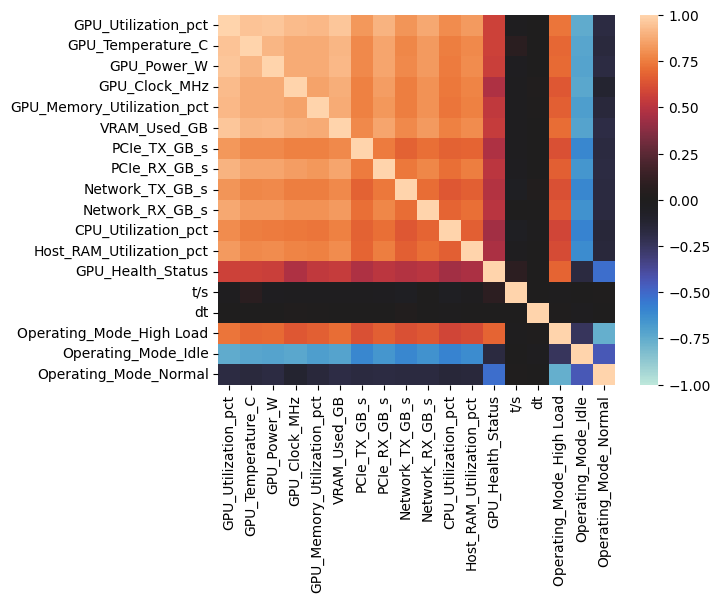

In [167]:

corr_matrix=df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr_matrix,vmin=-1.0,vmax=1.0,center=0.0)

In [168]:
corr_matrix?

In [171]:
display(corr_matrix['GPU_Health_Status'])

,GPU_Health_Status
GPU_Utilization_pct,0.567186
GPU_Temperature_C,0.570028
GPU_Power_W,0.559595
GPU_Clock_MHz,0.473390
GPU_Memory_Utilization_pct,0.529930
VRAM_Used_GB,0.544455
PCIe_TX_GB_s,0.475571
PCIe_RX_GB_s,0.509974
Network_TX_GB_s,0.485279
Network_RX_GB_s,0.502210


In [172]:
df_after_cleaning=df.copy()

In [175]:
feature_col=[col for col in df.select_dtypes(include=['int64','float64']) if col not in ['t/s','dt','GPU_Health_Status']]

In [176]:
feature_col

['GPU_Utilization_pct',
 'GPU_Temperature_C',
 'GPU_Power_W',
 'GPU_Clock_MHz',
 'GPU_Memory_Utilization_pct',
 'VRAM_Used_GB',
 'PCIe_TX_GB_s',
 'PCIe_RX_GB_s',
 'Network_TX_GB_s',
 'Network_RX_GB_s',
 'CPU_Utilization_pct',
 'Host_RAM_Utilization_pct',
 'Operating_Mode_High Load',
 'Operating_Mode_Idle',
 'Operating_Mode_Normal']

In [177]:
X=df[feature_col]
y=df['GPU_Health_Status']

In [179]:
print(X.shape)
print(y.shape)

(2390, 15)
(2390,)


In [193]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

model=RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    class_weight='balanced',
    random_state=42)
model.fit(X_train,y_train)

def evaluate_model(model,X_test,y_test):
  y_pred=model.predict(X_test)
  metrics_dict_test={
    'precision':precision_score(y_test,y_pred),
    'recall': recall_score(y_test,y_pred),
    'f1_score':f1_score(y_test,y_pred),
    'accuracy':accuracy_score(y_test,y_pred)
 }

  return metrics_dict_test

metrics_dict_test=evaluate_model(model,X_test,y_test)
metrics_dict_train=evaluate_model(model,X_train,y_train)

for key, value in metrics_dict_test.items():
  print(f"Test: {key}:{value}")

for key, value in metrics_dict_train.items():
  print(f"Train: {key}:{value}")

Test: precision:0.648854961832061
Test: recall:0.9883720930232558
Test: f1_score:0.783410138248848
Test: accuracy:0.9016736401673641
Train: precision:0.6660194174757281
Train: recall:0.997093023255814
Train: f1_score:0.7986030267753201
Train: accuracy:0.9095188284518828


In [195]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[346  46]
 [  1  85]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       392
           1       0.65      0.99      0.78        86

    accuracy                           0.90       478
   macro avg       0.82      0.94      0.86       478
weighted avg       0.93      0.90      0.91       478

